# Panel local projections: CPI on xi x oil

This notebook is a notebook-first version of the panel local-projections workflow.

It is designed so you can:

- change horizons, lag lengths, and fixed effects interactively,
- start with `cpi_pct_change` on `xi_x_oil`,
- add country-year controls later by editing a small `panel_controls` list,
- optionally trim CPI outliers with an IQR rule before estimation,
- inspect the base panel before we promote the workflow into a full CLI pipeline.


In [10]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

for path in [ROOT, ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import local_projections as lp


In [11]:
xi_path = ROOT / "data/processed/xi/regular/xi_by_country_year.parquet"
cpi_path = ROOT / "data/processed/cpi/quarterly_cpi.csv"
oil_path = ROOT / "data/processed/oil/quarterly_oil.csv"
cpi_freq = "Q"

# Add future controls here. These are merged into the panel.
# Example:
# panel_controls = [
#     {
#         "name": "exchange_rate",
#         "path": ROOT / "data/processed/exchange_rates/quarterly_exchange_rates.csv",
#         "value_column": "log_diff",
#         "merge_keys": ["country", "period"],
#         "merge_key_columns": {"country": "country_code", "period": "quarter"},
#         "status_column": None,
#     }
# ]
panel_controls = [
    {
        "name": "output_gap",
        "path": ROOT / "data/processed/real_gdp/quarterly_output_gap.csv",
        "value_column": "output_gap",
        "merge_keys": ["country", "period"],
        "status_column": "hp_filter_status",
        "ok_status": "ok",
    },
]

# Controls that actually enter the LP regression.
regression_controls = ["output_gap"]

horizons = 11
y_lags = 3
shock_lags = 3
control_lags = {"output_gap": 3}
include_country_fe = True
include_year_fe = True
cov_type = "cluster_country_time"
common_sample = True
remove_cpi_outliers = False
iqr_multiplier = 10
exclude_countries = [
    'AGO', 'ARE', 'ARG', 'BGD', 'BGR', 'BLR', 'BRA', 'BRN',
    'CAN', 'CHE', 'CHL', 'CHN', 'CIV', 'CMR', 'COD', 'COL',
    'CRI', 'CZE', 'DNK', 'EGY', 'GBR', 'HKG', 'HUN', 'IDN',
    'IND', 'ISL', 'ISR', 'JOR', 'JPN', 'KAZ', 'KHM', 'KOR',
    'LAO', 'MAR', 'MEX', 'MMR', 'MYS', 'NGA', 'NOR', 'NZL',
    'PAK', 'PER', 'PHL', 'POL', 'ROU', 'RUS', 'SAU', 'SEN',
    'SGP', 'STP', 'SWE', 'THA', 'TUN', 'TUR', 'TWN', 'UKR',
    'USA', 'VNM', 'ZAF'
]
sample_start = 2001
sample_end = None
lag_xi_by_one_year_for_xi_x_oil = True

print("horizons:", horizons)
print("y_lags:", y_lags)
print("shock_lags:", shock_lags)
print("control_lags:", control_lags)
print("include_country_fe:", include_country_fe)
print("include_year_fe:", include_year_fe)
print("cov_type:", cov_type)
print("common_sample:", common_sample)
print("remove_cpi_outliers:", remove_cpi_outliers)
print("iqr_multiplier:", iqr_multiplier)
print("panel_controls:", [spec["name"] for spec in panel_controls])
print("regression_controls:", regression_controls)
print("lag_xi_by_one_year_for_xi_x_oil:", lag_xi_by_one_year_for_xi_x_oil)


horizons: 11
y_lags: 3
shock_lags: 3
control_lags: {'output_gap': 3}
include_country_fe: True
include_year_fe: True
cov_type: cluster_country_time
common_sample: True
remove_cpi_outliers: False
iqr_multiplier: 10
panel_controls: ['output_gap']
regression_controls: ['output_gap']
lag_xi_by_one_year_for_xi_x_oil: True


In [12]:
panel_df = lp.build_panel_lp_dataset(
    xi_path=xi_path,
    cpi_path=cpi_path,
    oil_path=oil_path,
    cpi_freq=cpi_freq,
    lag_xi_by_one_year_for_xi_x_oil=lag_xi_by_one_year_for_xi_x_oil,
    controls=panel_controls,
    exclude_countries=exclude_countries,
    sample_start=sample_start,
    sample_end=sample_end,
)

diag_df = lp.panel_diagnostics(panel_df)
diag_df


,rows,countries,year_min,year_max,avg_years_per_country,period_min,period_max,avg_periods_per_country
0,1848,21,2001,2022,22.0,2001-Q1,2022-Q4,88.0


In [13]:
panel_df.head()


,country,year,period,time_index,xi,oil_pct_change,xi_x_oil,cpi_pct_change,xi_amp_1,xi_amp_2,xi_amp,output_gap
0,AUS,2001,2001-Q1,8004,0.024699,-0.122910,-0.003570,0.010944,0.005140,0.009746,0.014886,-0.008858
1,AUS,2001,2001-Q2,8005,0.024699,0.025693,0.000746,0.008119,0.005140,0.009746,0.014886,-0.008799
2,AUS,2001,2001-Q3,8006,0.024699,-0.056254,-0.001634,0.002685,0.005140,0.009746,0.014886,-0.006044
3,AUS,2001,2001-Q4,8007,0.024699,-0.270271,-0.007849,0.009371,0.005140,0.009746,0.014886,-0.002764
4,AUS,2002,2002-Q1,8008,0.025219,0.077184,0.001906,0.009284,0.005173,0.010232,0.015405,-0.003546


In [14]:
panel_df_model = panel_df.copy()

if remove_cpi_outliers:
    q1 = panel_df_model["cpi_pct_change"].quantile(0.25)
    q3 = panel_df_model["cpi_pct_change"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_multiplier * iqr
    upper = q3 + iqr_multiplier * iqr
    panel_df_model = panel_df_model.loc[
        panel_df_model["cpi_pct_change"].between(lower, upper)
    ].copy()
    print(f"CPI IQR fence: [{lower:.6f}, {upper:.6f}]")
    print("Rows after CPI outlier filter:", len(panel_df_model))
    print("Dropped rows:", len(panel_df) - len(panel_df_model))
else:
    print("CPI outlier filter disabled.")
    print("Rows kept:", len(panel_df_model))

panel_df_model.head()


CPI outlier filter disabled.
Rows kept: 1848


,country,year,period,time_index,xi,oil_pct_change,xi_x_oil,cpi_pct_change,xi_amp_1,xi_amp_2,xi_amp,output_gap
0,AUS,2001,2001-Q1,8004,0.024699,-0.122910,-0.003570,0.010944,0.005140,0.009746,0.014886,-0.008858
1,AUS,2001,2001-Q2,8005,0.024699,0.025693,0.000746,0.008119,0.005140,0.009746,0.014886,-0.008799
2,AUS,2001,2001-Q3,8006,0.024699,-0.056254,-0.001634,0.002685,0.005140,0.009746,0.014886,-0.006044
3,AUS,2001,2001-Q4,8007,0.024699,-0.270271,-0.007849,0.009371,0.005140,0.009746,0.014886,-0.002764
4,AUS,2002,2002-Q1,8008,0.025219,0.077184,0.001906,0.009284,0.005173,0.010232,0.015405,-0.003546


In [15]:
irf_df, coef_df, models = lp.fit_panel_local_projections(
    panel_df_model,
    y_col="cpi_pct_change",
    shock_col="xi_x_oil",
    horizons=horizons,
    y_lags=y_lags,
    shock_lags=shock_lags,
    controls=regression_controls,
    control_lags=control_lags,
    include_country_fe=include_country_fe,
    include_year_fe=include_year_fe,
    cov_type=cov_type,
    common_sample=common_sample,
)

irf_df


c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\regression\linear_model.py:1884: RuntimeWarning: invalid value 

,horizon,term,coef,std_err_cluster_country_time,t,p_value,ci_low_95,ci_high_95,nobs,n_countries
0,0,xi_x_oil,-0.039415,0.057680,-0.683353,0.494384,-0.152465,0.073634,1554.0,21
1,1,xi_x_oil,-0.110385,0.091482,-1.206629,0.227575,-0.289686,0.068916,1554.0,21
2,2,xi_x_oil,0.096121,0.025452,3.776469,0.000159,0.046235,0.146007,1554.0,21
3,3,xi_x_oil,0.136184,0.047341,2.876652,0.004019,0.043397,0.228972,1554.0,21
4,4,xi_x_oil,0.025490,0.053001,0.480929,0.630567,-0.078391,0.129370,1554.0,21
5,5,xi_x_oil,-0.064686,0.028875,-2.240197,0.025078,-0.121280,-0.008092,1554.0,21
6,6,xi_x_oil,0.005093,0.046592,0.109316,0.912952,-0.086225,0.096411,1554.0,21
7,7,xi_x_oil,0.040462,0.047363,0.854302,0.392938,-0.052367,0.133291,1554.0,21
8,8,xi_x_oil,-0.056990,0.051536,-1.105820,0.268804,-0.157999,0.044019,1554.0,21
9,9,xi_x_oil,-0.172969,0.057644,-3.000662,0.002694,-0.285948,-0.059990,1554.0,21


In [16]:
coef_df.loc[coef_df["term"].isin(["xi_x_oil", "const"])].head(10)


,horizon,term,coef,std_err_cluster_country_time,t,p_value,ci_low_95,ci_high_95,nobs
0,0,const,0.004396,0.001077,4.082022,4.464548e-05,0.002285,0.006507,1554.0
1,0,xi_x_oil,-0.039415,0.057680,-0.683353,4.943841e-01,-0.152465,0.073634,1554.0
104,1,const,0.005756,0.000929,6.198588,5.697197e-10,0.003936,0.007576,1554.0
105,1,xi_x_oil,-0.110385,0.091482,-1.206629,2.275750e-01,-0.289686,0.068916,1554.0
208,2,const,0.005062,0.000907,5.582465,2.371332e-08,0.003285,0.006840,1554.0
209,2,xi_x_oil,0.096121,0.025452,3.776469,1.590671e-04,0.046235,0.146007,1554.0
312,3,const,0.004491,0.000712,6.306287,2.858089e-10,0.003096,0.005887,1554.0
313,3,xi_x_oil,0.136184,0.047341,2.876652,4.019181e-03,0.043397,0.228972,1554.0
416,4,const,0.009173,0.000199,46.034505,0.000000e+00,0.008783,0.009564,1554.0
417,4,xi_x_oil,0.025490,0.053001,0.480929,6.305672e-01,-0.078391,0.129370,1554.0


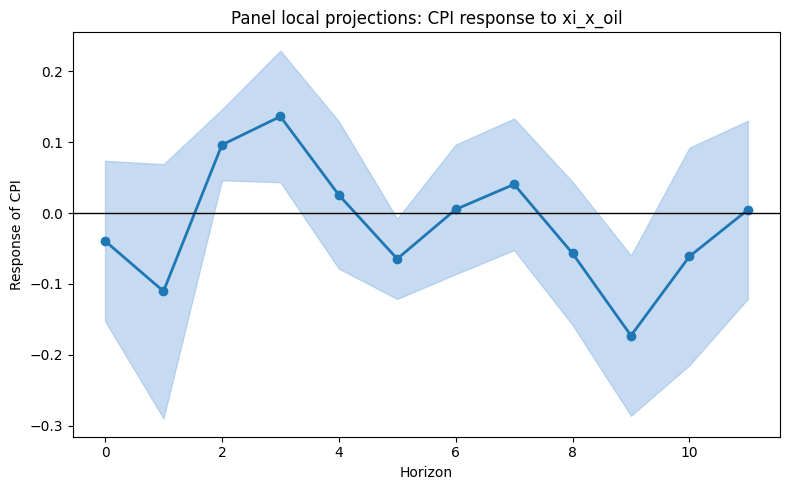

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
lp.plot_irf(irf_df, ax=ax)
plt.tight_layout()
plt.show()


In [18]:
horizon_to_inspect = 0
print(models[horizon_to_inspect].summary())


                             OLS Regression Results                             
Dep. Variable:     cpi_pct_change_lead0   R-squared:                       0.524
Model:                              OLS   Adj. R-squared:                  0.490
Method:                   Least Squares   F-statistic:                    -9.767
Date:                  Sat, 11 Apr 2026   Prob (F-statistic):               1.00
Time:                          19:12:46   Log-Likelihood:                 5695.7
No. Observations:                  1554   AIC:                        -1.118e+04
Df Residuals:                      1450   BIC:                        -1.063e+04
Df Model:                           103                                         
Covariance Type:                cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const         